In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
import missingno as msno
import geopandas as gpd
from geopandas.tools import geocode
from warnings import filterwarnings

filterwarnings("ignore")
df = pd.read_csv("../../data/interim/data1.csv")

In [2]:
df.isnull().sum()

Date Text     0
Text Text     3
location      0
oblast       70
date          0
time          0
timezone      0
Year          0
Month         0
Day           0
Season        0
AM_PM         0
dtype: int64

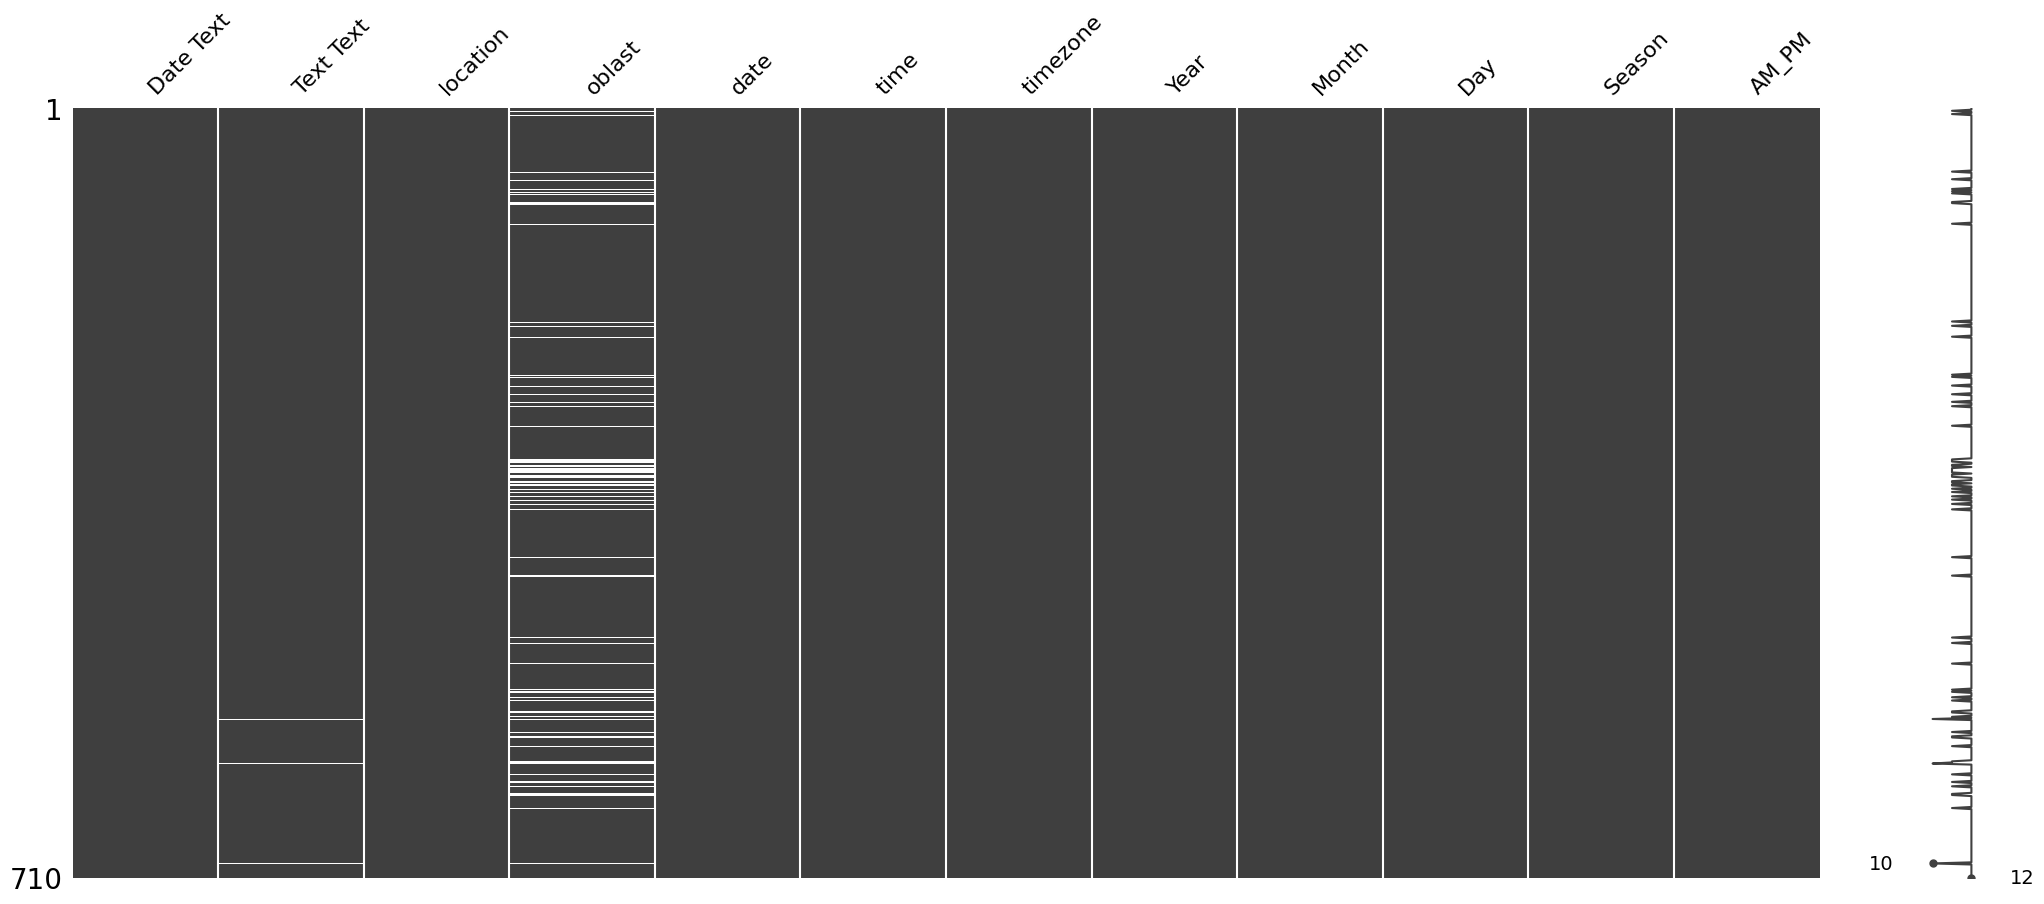

In [3]:
msno.matrix(df);

In [4]:
for i in df.columns:
    if len(df[i].unique())<30:
        print(f"{i}:",df[i].unique())

oblast: ['donetsk' 'kherson' 'zaporizhzhia' nan 'dnipropetrovsk' 'belgorod'
 'luhansk' 'kharkiv' 'bryansk' 'kursk' 'sumy' 'zaporizhia' 'kaliningrad'
 'mykolaiv' 'novgorod' 'tver' 'samara' 'irkutsk' 'odesa' 'tambov'
 'voronezh' 'smolensk' 'rostov']
Year: [2023 2024]
Month: [ 7  8  9 10 11 12  1  2]
Season: ['Summer' 'Fall' 'Winter']
AM_PM: ['PM' 'AM']


## Pivot of [AMPM D-M-Y] index, Oblast Column

In [5]:
pivot_df = pd.pivot_table(df, values='Text Text',
                        index=['AM_PM','Day','Month','Year'], columns='oblast', 
                        aggfunc='sum', fill_value=0
                   )
text_columns = [col for col in pivot_df.columns if pivot_df[col].dtype == 'O']
pivot_df[text_columns] = pivot_df[text_columns].applymap(lambda x: 1 if isinstance(x, str) else 0)
pivot_df.to_csv("../../data/processed/TDMYpivot.csv", index=False)
pivot_df

oblast                belgorod  bryansk  dnipropetrovsk  donetsk  irkutsk  \
AM_PM Day Month Year                                                        
AM    1   1     2024         0        0               0        1        0   
          8     2023         0        0               0        0        0   
          10    2023         0        0               0        1        0   
      2   7     2023         0        0               0        0        0   
          8     2023         0        0               0        1        0   
...                        ...      ...             ...      ...      ...   
PM    30  11    2023         0        0               1        1        0   
          12    2023         1        0               0        1        0   
      31  1     2024         0        0               0        1        0   
          7     2023         1        0               0        0        0   
          10    2023         0        0               0        1        0   

oblast                kaliningrad  kharkiv  kherson  kursk  luhansk  ...  \
AM_PM Day Month Year                                                 ...   
AM    1   1     2024            0        0        0      0        0  ...   
          8     2023            0        0        0      0        1  ...   
          10    2023            0        0        1      0        0  ...   
      2   7     2023            0        0        1      0        0  ...   
          8     2023            0        0        0      0        0  ...   
...                           ...      ...      ...    ...      ...  ...   
PM    30  11    2023            0        1        0      0        0  ...   
          12    2023            0        0        0      0        1  ...   
      31  1     2024            0        0        0      0        0  ...   
          7     2023            0        0        0      0        0  ...   
          10    2023            0        0        1      0        0  ...   

oblast                odesa  rostov  samara  smolensk  sumy  tambov  tver  \
AM_PM Day Month Year                                                        
AM    1   1     2024      0       0       0         0     0       0     0   
          8     2023      0       0       0         0     0       0     0   
          10    2023      0       0       0         0     0       0     0   
      2   7     2023      0       0       0         0     0       0     0   
          8     2023      0       0       0         0     0       0     0   
...                     ...     ...     ...       ...   ...     ...   ...   
PM    30  11    2023      0       0       0         0     0       0     0   
          12    2023      0       0       0         0     0       0     0   
      31  1     2024      0       0       0         0     0       0     0   
          7     2023      0       0       0         0     0       0     0   
          10    2023      0       0       0         0     0       0     0   

oblast                voronezh  zaporizhia  zaporizhzhia  
AM_PM Day Month Year                                      
AM    1   1     2024         0           0             0  
          8     2023         0           0             0  
          10    2023         0           0             0  
      2   7     2023         0           0             1  
          8     2023         0           0             0  
...                        ...         ...           ...  
PM    30  11    2023         0           0             0  
          12    2023         0           0             0  
      31  1     2024         0           0             0  
          7     2023         0           0             0  
          10    2023         0           0             0  

[316 rows x 22 columns]

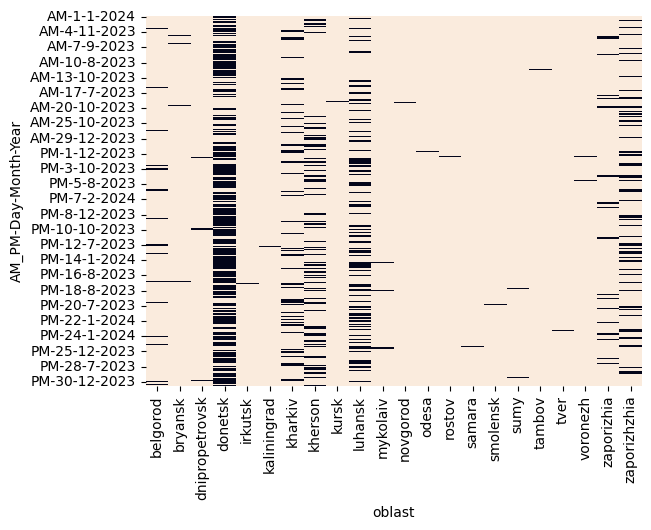

In [6]:
sbn.heatmap(pivot_df==0, cbar=False);

## Pivot of Season index, Oblast column

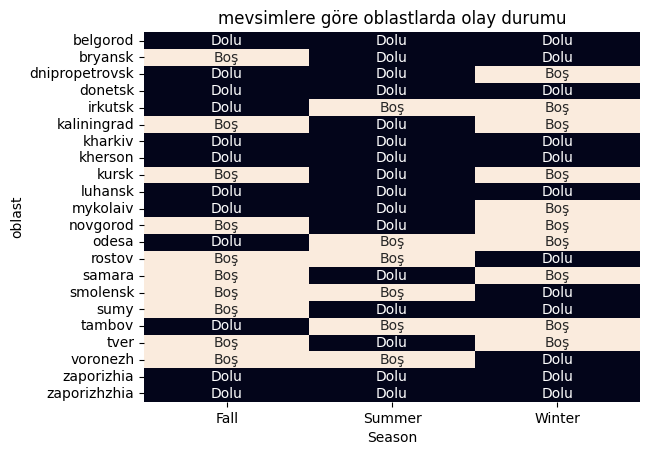

In [7]:
pivot_df = pd.pivot_table(df, values='Text Text', index='Season', 
               columns='oblast', aggfunc='sum', fill_value=0
                   ).T

custom_annot = pivot_df.applymap(lambda x: 'Boş' if x == 0 else 'Dolu')

plt.title("mevsimlere göre oblastlarda olay durumu");
sbn.heatmap(pivot_df==0,
                   annot=custom_annot, fmt="",
                   cbar=False);

## Pivot of [M-Y] index, Oblast column

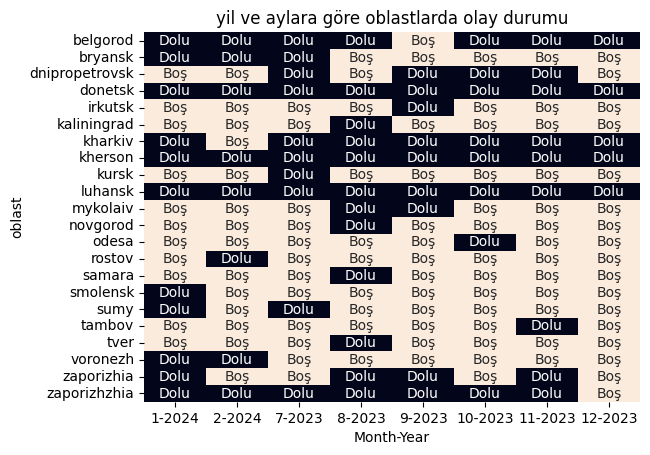

In [8]:
pivot_df = pd.pivot_table(df, values='Text Text', 
                        index=['Month',"Year"], columns='oblast', 
                        aggfunc='sum', fill_value=0
                   )
text_columns = [col for col in pivot_df.columns if pivot_df[col].dtype == 'O']
pivot_df[text_columns] = pivot_df[text_columns].applymap(lambda x: 1 if isinstance(x, str) else 0)
pivot_df.to_csv("../../data/processed/MYpivot.csv", index=False)

plt.title("yil ve aylara göre oblastlarda olay durumu");
custom_annot = pivot_df.T.applymap(lambda x: 'Boş' if x == 0 else 'Dolu')
sbn.heatmap(
    pivot_df.T==0,
            annot=custom_annot,fmt="",
            cbar=False);

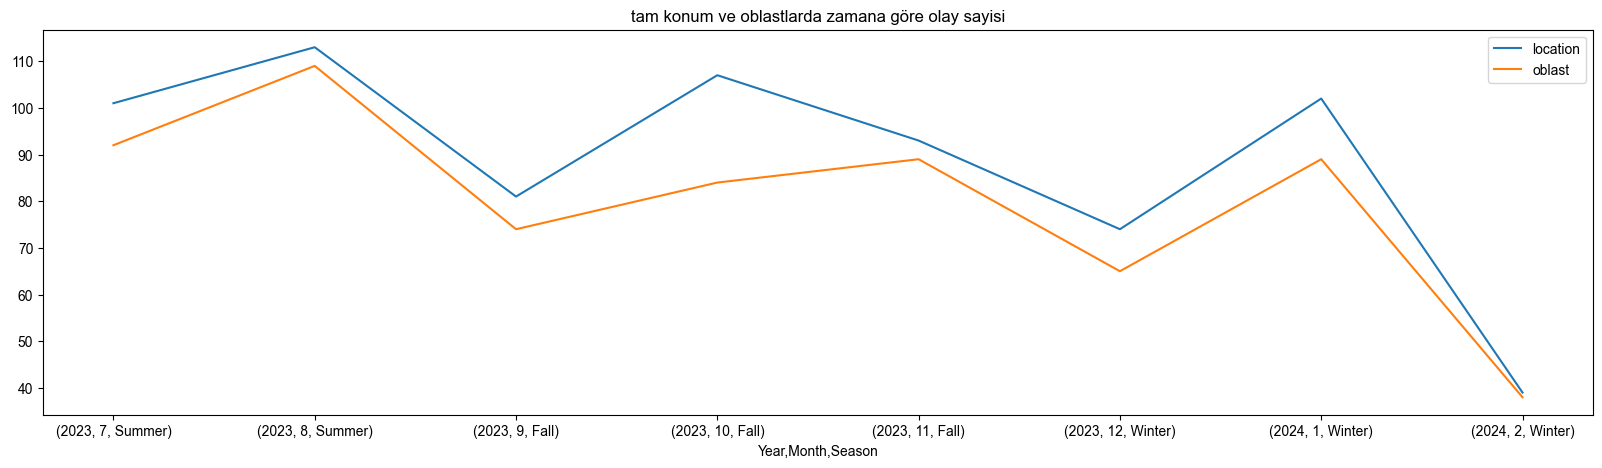

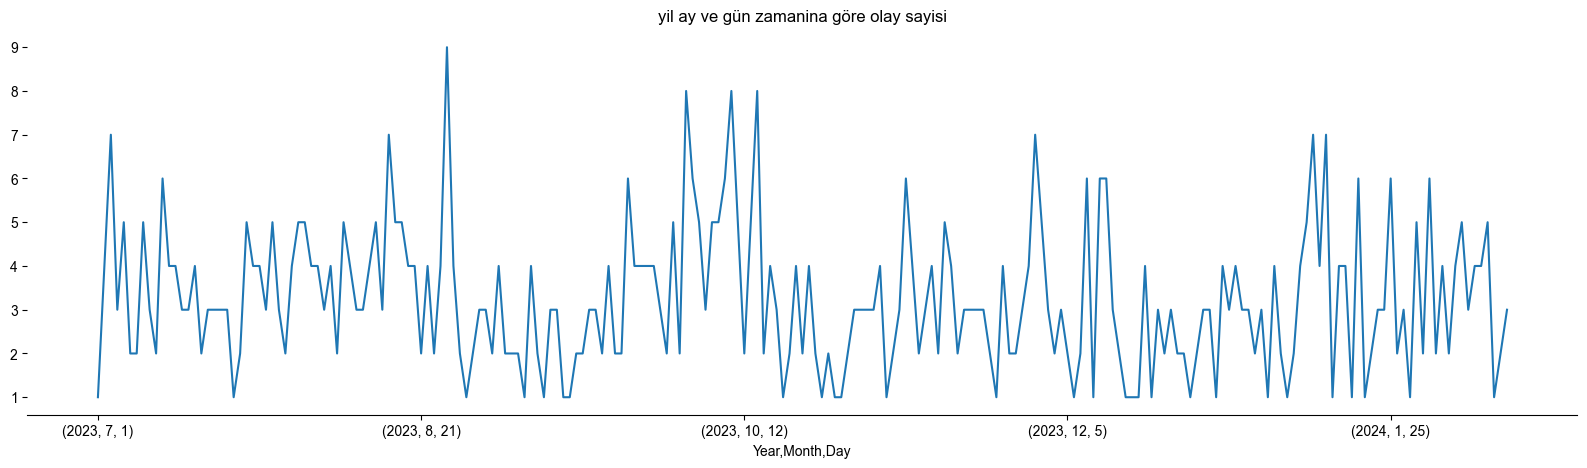

In [9]:
plt.figure(figsize=(20,5));
plt.title("tam konum ve oblastlarda zamana göre olay sayisi");
df.groupby(["Year","Month","Season"]).count()["location"].plot(label="location");
df.groupby(["Year","Month","Season"]).count()["oblast"].plot(label="oblast");
plt.legend();

plt.figure(figsize=(20,5));
plt.title("yil ay ve gün zamanina göre olay sayisi");
df[["Year","Month","Day"]].value_counts().sort_index().plot();

sbn.set_style("whitegrid")
sbn.despine(left=True,top=True)

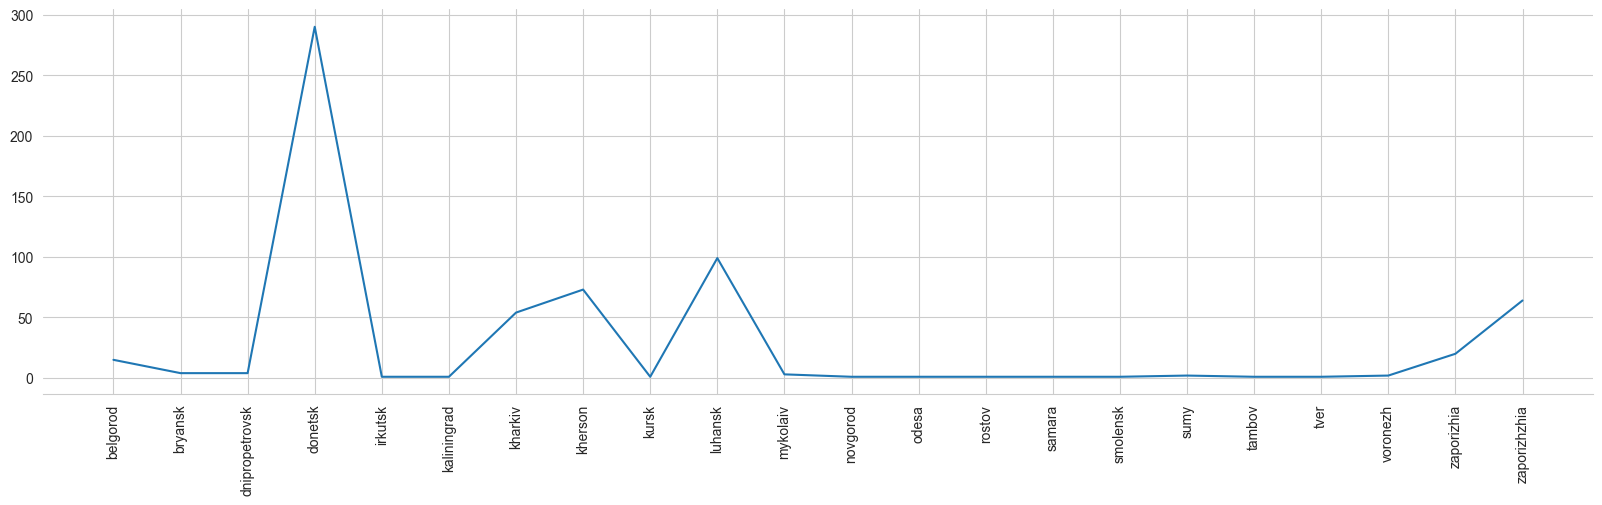

In [10]:
plt.figure(figsize=(20,5));
plt.plot(df[["date","oblast"]].groupby("oblast").count());
plt.xticks(rotation=90);
sbn.set_style("whitegrid")
sbn.despine(left=True,top=True)

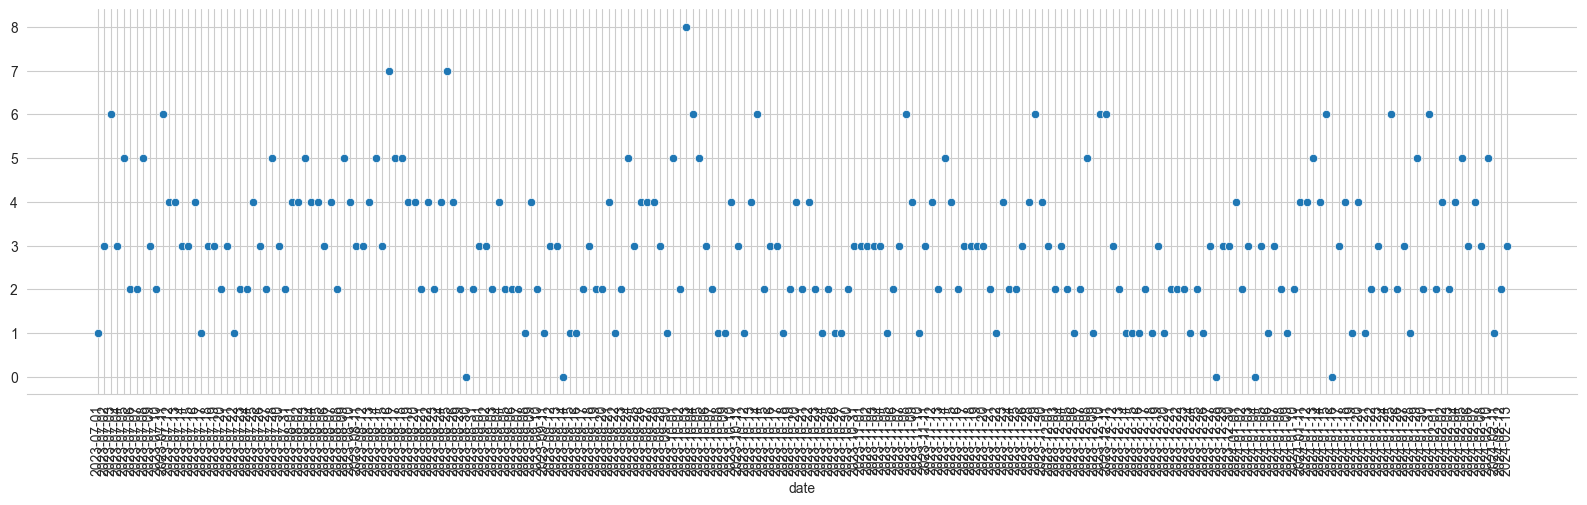

In [11]:
plt.figure(figsize=(20,5));
sbn.scatterplot(x=df[["date","oblast"]].groupby("date").count().index,
             y=df[["date","oblast"]].groupby("date").count().values.reshape(219));
plt.xticks(rotation=90);
sbn.set_style("whitegrid")
sbn.despine(left=True,top=True)

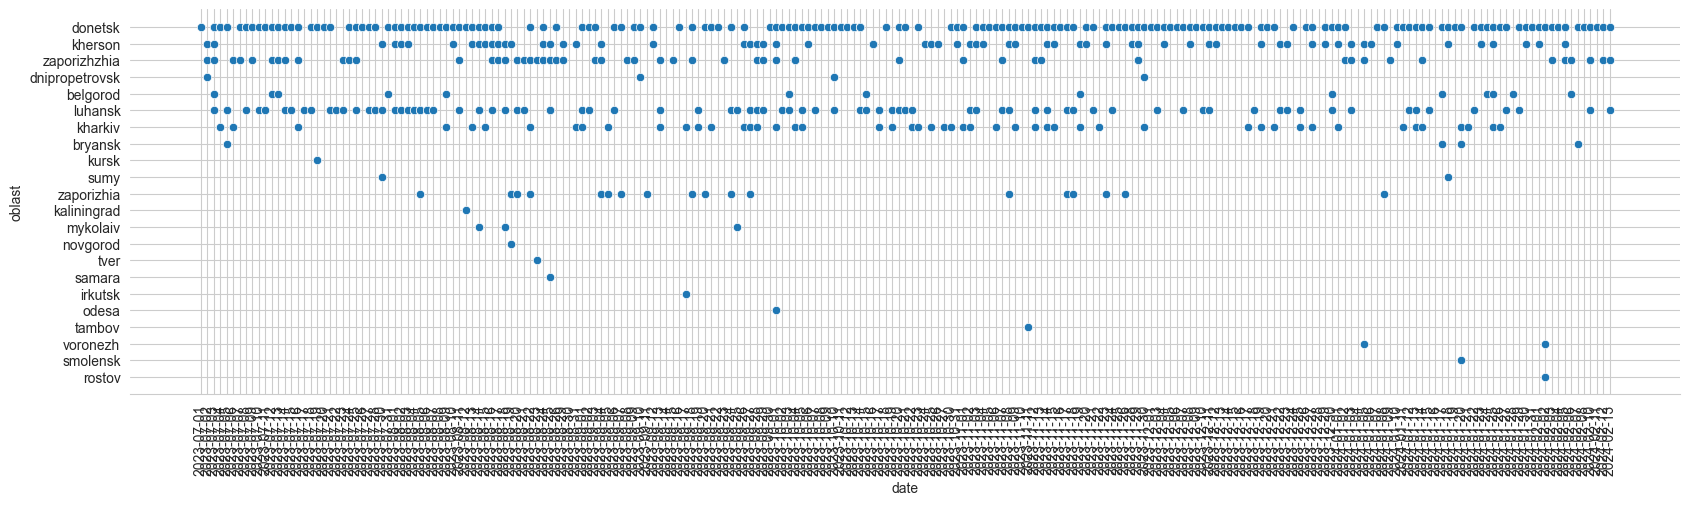

In [12]:
plt.figure(figsize=(20,5));
sbn.scatterplot(x="date",y="oblast",data=df);
plt.xticks(rotation=90);
sbn.set_style("whitegrid")
sbn.despine(left=True,top=True)

In [17]:
import geopandas as gp
import geopy
import contextily as ctx
import pandas as pd
data = pd.read_csv("../../data/interim/points.csv")

dfg = gp.GeoDataFrame(data)
dfg.head()

,geometry,address
0,POINT (37.405817 47.7266739),"Володимирівка, 85721-85723, Донецька область, ..."
1,POINT (32.7220187 46.6260908),"Олешки, 75100-75108, Херсонська область, Україна"
2,POINT (35.544201 46.73275),"Новопокровка, 72443, Запорізька область, Україна"
3,POINT (38.1554803 46.043181),"Приморско-Ахтарск, Краснодарский край, Россия"
4,POINT (34.447971 48.396149),"Іллінка, 52314, Дніпропетровська область, Україна"


In [19]:
dfg["geometry"].astype("geometry")

TypeError: Input must be valid geometry objects: POINT (37.405817 47.7266739)

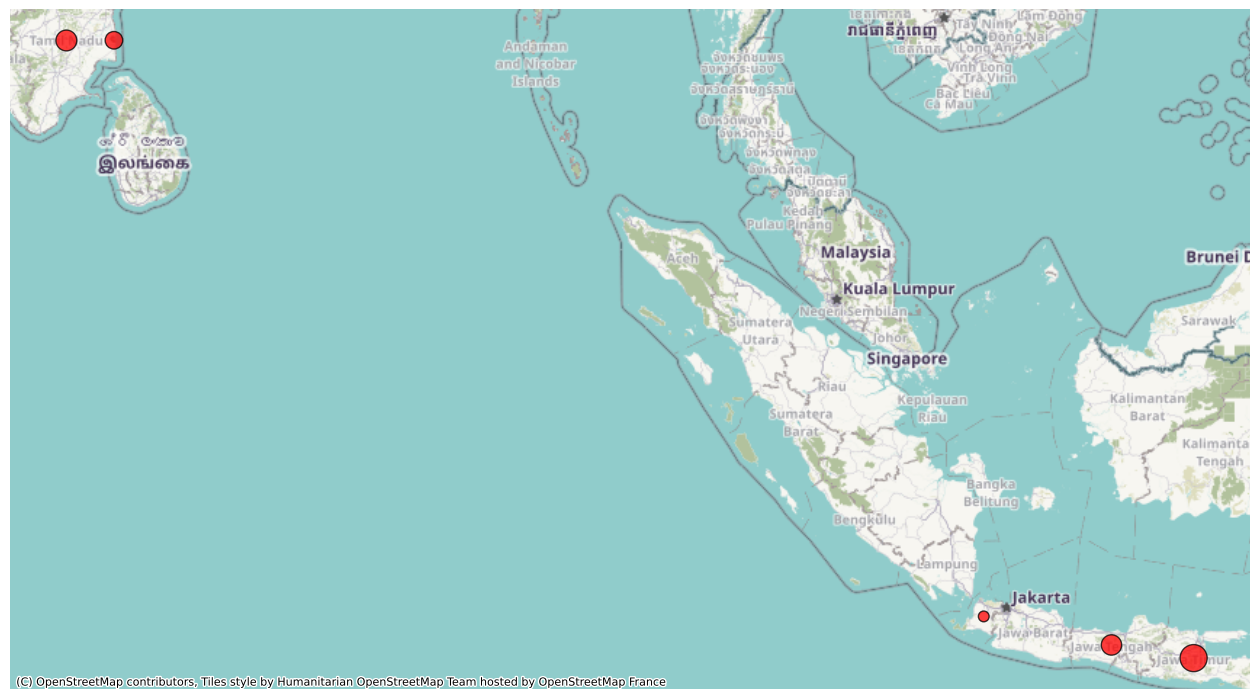

In [9]:
dfg = dfg.to_crs(epsg=3857)
ax = dfg.plot(figsize=(16, 10), alpha=0.75, edgecolor='k', marker='o', color='red', markersize=dfg.Reach*5)
ctx.add_basemap(ax)
ax.set_axis_off()